In [1]:
import pandas as pd
import PIL
from PIL import Image

In [2]:
# Read the file and load into a DataFrame
ground_truth_df = pd.read_csv('ml_exercise_therapanacea/label_train.txt', header=None, names=['label'])
ground_truth_df.index = ground_truth_df.index + 1
ground_truth_df

,label
1,1
2,1
3,1
4,1
5,1
...,...
99996,1
99997,1
99998,1
99999,1


In [3]:
ground_truth_df.describe()

,label
count,100000.000000
mean,0.878980
std,0.326152
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


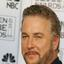

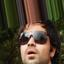

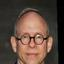

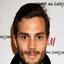

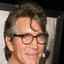

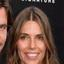

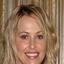

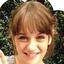

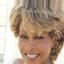

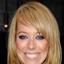

In [4]:
all_zeros = ground_truth_df[ground_truth_df['label'] == 0].index.to_list()
for x in all_zeros[100:105]:
    img=Image.open(f'ml_exercise_therapanacea/train_img/{x:06d}.jpg')
    display(img)

all_ones = ground_truth_df[ground_truth_df['label'] == 1].index.to_list()
for x in all_ones[100:105]:
    img=Image.open(f'ml_exercise_therapanacea/train_img/{x:06d}.jpg')
    display(img)

In [5]:
import torchvision
from torchvision.models import EfficientNet_B0_Weights

m = torchvision.models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
m

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [6]:
t = EfficientNet_B0_Weights.IMAGENET1K_V1.transforms()
t

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [7]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class CelebASubsetDataset(Dataset):
    def __init__(self, img_folder, ground_truth_df, indices=None, transform=None):
        self.img_folder = img_folder
        self.ground_truth_df = ground_truth_df
        self.transform = transform
        if indices is None:
            self.indices = self.ground_truth_df.index.tolist()
        else:
            self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_idx = self.indices[idx]
        img_path = f"{self.img_folder}/{img_idx:06d}.jpg"
        image = Image.open(img_path).convert("RGB")
        label = self.ground_truth_df.loc[img_idx, 'label']
        if self.transform:
            transf_image = self.transform(image)
        return image, transf_image, label

In [10]:
myds = CelebASubsetDataset(
    img_folder='ml_exercise_therapanacea/train_img',
    ground_truth_df=ground_truth_df,
    indices=list(range(1, 30)),
    transform=t
)

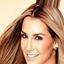

brassiere


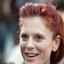

neck brace


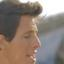

panpipe


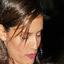

fur coat


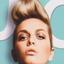

face powder


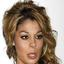

neck brace


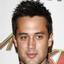

Windsor tie


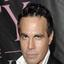

Windsor tie


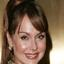

oboe


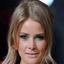

oboe


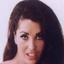

neck brace


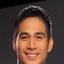

Windsor tie


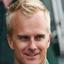

neck brace


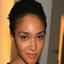

Windsor tie


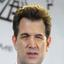

Windsor tie


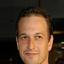

Windsor tie


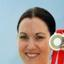

bearskin


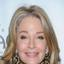

oboe


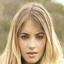

maillot tank suit


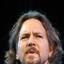

neck brace


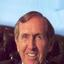

Sussex spaniel


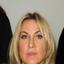

neck brace


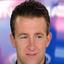

Windsor tie


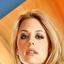

hair spray


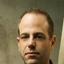

Windsor tie


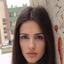

abaya


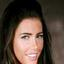

abaya


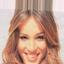

neck brace


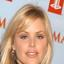

maillot tank suit


In [13]:
m.eval()
class_labels = EfficientNet_B0_Weights.IMAGENET1K_V1.meta["categories"]

for x in range(len(myds)):
    img, transf_img, label = myds[x]
    display(img)
    model_output = m(transf_img.unsqueeze(0))
    print(class_labels[torch.argmax(model_output, dim=1).item()])